<a href="https://colab.research.google.com/github/Amal-Joshy-T/ML-and-DL-Projects/blob/main/HeartAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Problem statement
 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/Patients Data ( Used for Heart Disease Prediction ) (1) (2).csv', encoding='latin1')
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

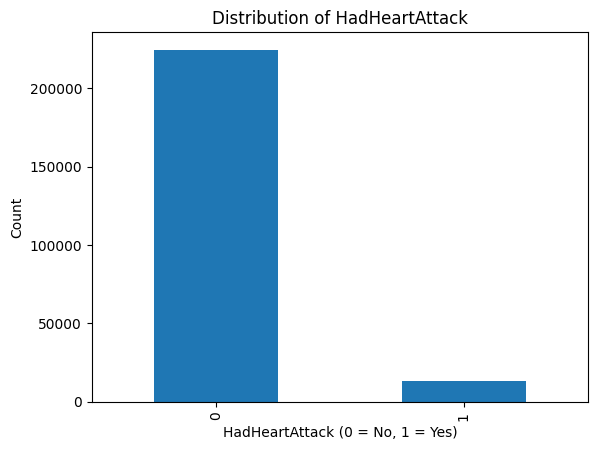

In [ ]:
plt.figure()
df['HadHeartAttack'].value_counts().plot(kind='bar')
plt.xlabel('HadHeartAttack (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Distribution of HadHeartAttack')
plt.show()


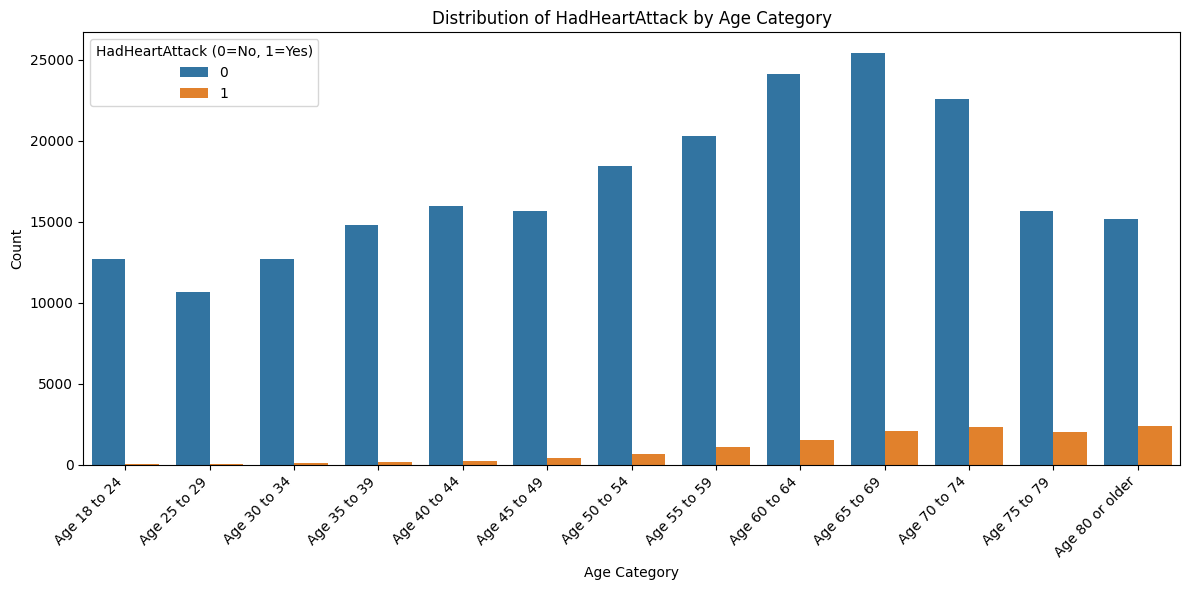

In [ ]:
age_category_order = [
    'Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39',
    'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59',
    'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
    'Age 80 or older'
]

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='AgeCategory', hue='HadHeartAttack', order=age_category_order)
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.title('Distribution of HadHeartAttack by Age Category')
plt.xticks(rotation=45, ha='right')
plt.legend(title='HadHeartAttack (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

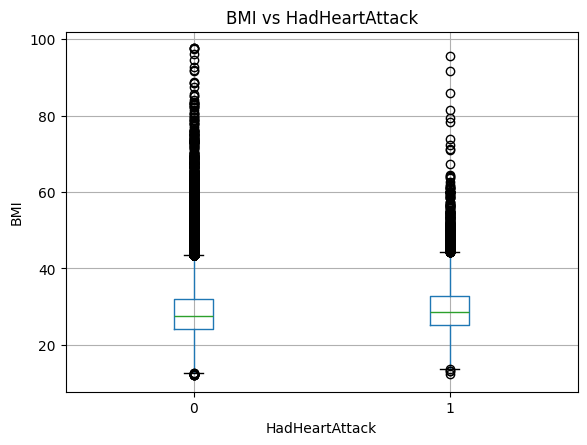

In [ ]:
plt.figure()
df.boxplot(column='BMI', by='HadHeartAttack')
plt.xlabel('HadHeartAttack')
plt.ylabel('BMI')
plt.title('BMI vs HadHeartAttack')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

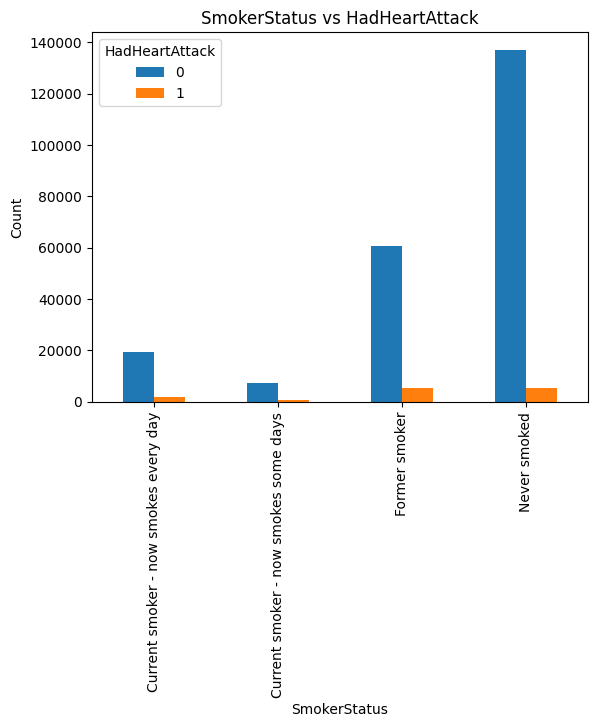

In [ ]:
plt.figure()
pd.crosstab(df['SmokerStatus'], df['HadHeartAttack']).plot(kind='bar')
plt.xlabel('SmokerStatus')
plt.ylabel('Count')
plt.title('SmokerStatus vs HadHeartAttack')
plt.show()

<Figure size 640x480 with 0 Axes>

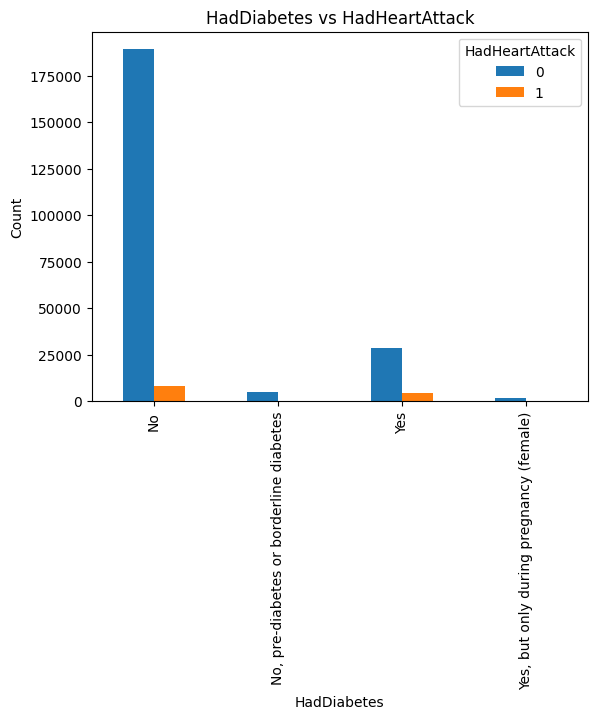

In [ ]:

plt.figure()
pd.crosstab(df['HadDiabetes'], df['HadHeartAttack']).plot(kind='bar')
plt.xlabel('HadDiabetes')
plt.ylabel('Count')
plt.title('HadDiabetes vs HadHeartAttack')
plt.show()

<Figure size 640x480 with 0 Axes>

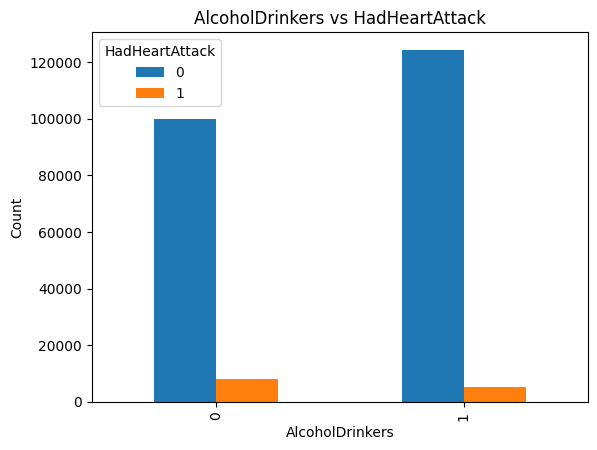

In [ ]:
plt.figure()
pd.crosstab(df['AlcoholDrinkers'], df['HadHeartAttack']).plot(kind='bar')
plt.xlabel('AlcoholDrinkers')
plt.ylabel('Count')
plt.title('AlcoholDrinkers vs HadHeartAttack')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'California', 'Arkansas',
       'Connecticut', 'Colorado', 'Delaware', 'Florida', 'Georgia',
       'Hawaii', 'Idaho', 'Indiana', 'District of Columbia', 'Kansas',
       'Iowa', 'Maryland', 'Minnesota', 'Montana', 'New Jersey',
       'Nebraska', 'New York', 'Ohio', 'Oklahoma', 'Texas', 'Vermont',
       'Washington', 'Utah', 'Illinois', 'West Virginia', 'Virginia',
       'Massachusetts', 'Kentucky', 'Louisiana', 'Maine', 'Wisconsin',
       'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire',
       'New Mexico', 'South Carolina', 'North Carolina', 'North Dakota',
       'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota',
       'Tennessee', 'Wyoming', 'Guam', 'Puerto Rico', 'Virgin Islands'],
      dtype=object)

In [ ]:
df['Sex'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df["Sex"].replace({"Male": 1, "Female": 0}, inplace=True)

/tmp/ipython-input-777072302.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sex"].replace({"Male": 1, "Female": 0}, inplace=True)
/tmp/ipython-input-777072302.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sex"].replace({"Male": 1, "Female": 0}, inplace=True)


In [ ]:
df['GeneralHealth'].unique()

array(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'], dtype=object)

In [ ]:
df["GeneralHealth"].replace({
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very good": 3,
    "Excellent": 4
}, inplace=True)

/tmp/ipython-input-2815445070.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace({
/tmp/ipython-input-2815445070.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace({


In [ ]:
df['AgeCategory'].unique()

array(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'], dtype=object)

In [ ]:
df['AgeCategory'].replace({'Age 18 to 24': 21, 'Age 25 to 29': 27, 'Age 30 to 34': 32,
    'Age 35 to 39': 37, 'Age 40 to 44': 42, 'Age 45 to 49': 47,
    'Age 50 to 54': 52, 'Age 55 to 59': 57, 'Age 60 to 64': 62,
    'Age 65 to 69': 67, 'Age 70 to 74': 72, 'Age 75 to 79': 77,
    'Age 80 or older': 82},inplace=True)

/tmp/ipython-input-1439387723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace({'Age 18 to 24': 21, 'Age 25 to 29': 27, 'Age 30 to 34': 32,
/tmp/ipython-input-1439387723.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['AgeCategory'].replace({'Age 18 to 24': 21, 'A

In [ ]:
df['HadDiabetes'].unique()

array(['Yes', 'No', 'No, pre-diabetes or borderline diabetes',
       'Yes, but only during pregnancy (female)'], dtype=object)

In [ ]:
df['HadDiabetes'].replace({'No': 0,
    'Yes, but only during pregnancy (female)': 0,
    'No, pre-diabetes or borderline diabetes': 1,
    'Yes': 2},inplace=True)

/tmp/ipython-input-2514024207.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HadDiabetes'].replace({'No': 0,
/tmp/ipython-input-2514024207.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['HadDiabetes'].replace({'No': 0,


In [ ]:
df['SmokerStatus'].unique()

array(['Former smoker', 'Never smoked',
       'Current smoker - now smokes every day',
       'Current smoker - now smokes some days'], dtype=object)

In [ ]:
df['SmokerStatus'].replace({'Never smoked': 0,
    'Current smoker - now smokes some days': 1,
    'Current smoker - now smokes every day': 2,
    'Former smoker': 1.5},inplace=True)

/tmp/ipython-input-1817663776.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SmokerStatus'].replace({'Never smoked': 0,
/tmp/ipython-input-1817663776.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SmokerStatus'].replace({'Never smoked': 0,


In [ ]:
df['ECigaretteUsage'].unique()

array(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'], dtype=object)

In [ ]:
df['ECigaretteUsage'].replace({'Never used e-cigarettes in my entire life': 0,
    'Not at all (right now)': 1,
    'Use them some days': 2,
    'Use them every day': 3},inplace=True)

/tmp/ipython-input-2895838593.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ECigaretteUsage'].replace({'Never used e-cigarettes in my entire life': 0,
/tmp/ipython-input-2895838593.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ECigaretteUsage'].replace({'Never used e-cigarettes i

In [ ]:
df['RaceEthnicityCategory'].unique()

array(['White only, Non-Hispanic', 'Black only, Non-Hispanic',
       'Other race only, Non-Hispanic', 'Multiracial, Non-Hispanic',
       'Hispanic'], dtype=object)

In [ ]:
df['TetanusLast10Tdap'].unique()

array(['No, did not receive any tetanus shot in the past 10 years',
       'Yes, received Tdap',
       'Yes, received tetanus shot but not sure what type',
       'Yes, received tetanus shot, but not Tdap'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from imblearn.over_sampling import SMOTE

# Split features and target
X = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


In [ ]:
import pandas as pd

# Combine X_smote and y_smote into one DataFrame
df_cleaned = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="HadHeartAttack")],
    axis=1
)


In [ ]:
df=df_cleaned

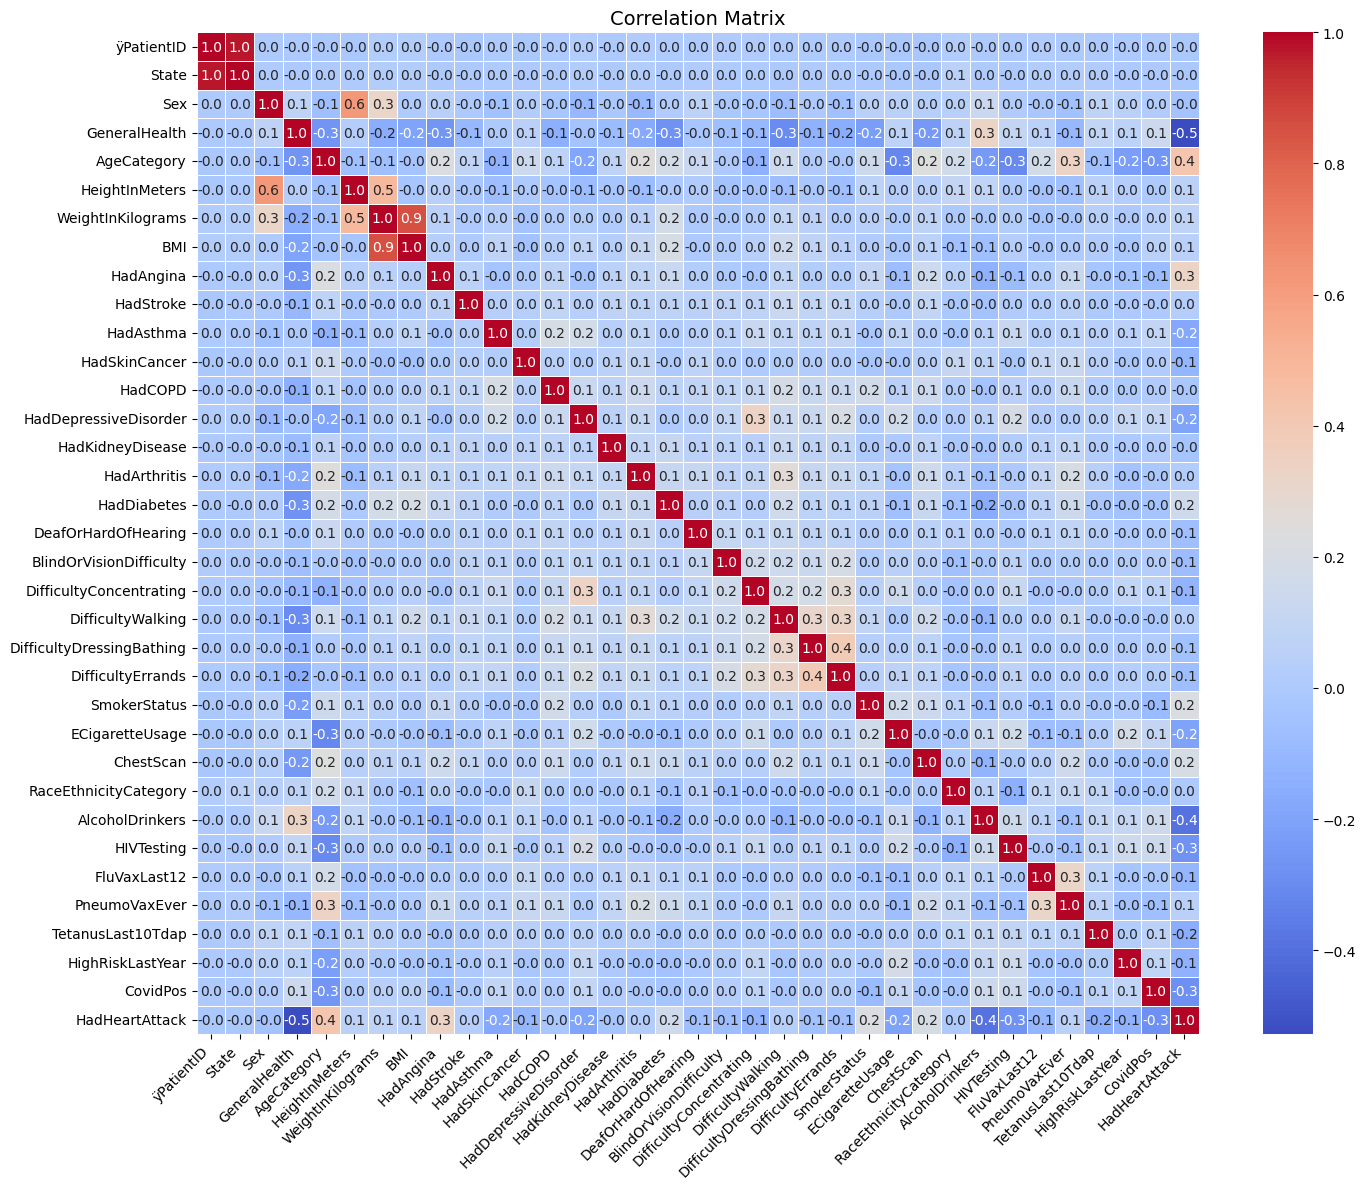

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".01f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['ÿPatientID','WeightInKilograms'], inplace=True)

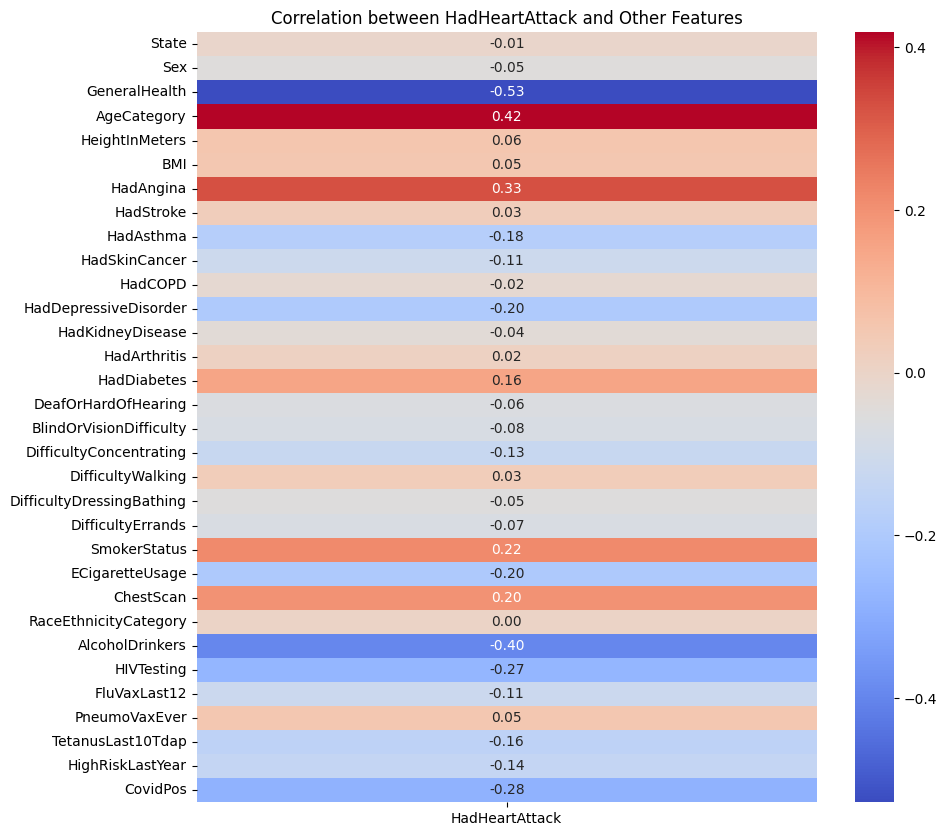

In [ ]:
HadHeartAttack_corr = df.corr()['HadHeartAttack']


HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')
plt.figure(figsize=(10, 10))
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between HadHeartAttack and Other Features')

plt.show()

In [ ]:
df.drop(['State','Sex','HeightInMeters','BMI','HadAsthma','HadSkinCancer','HadDepressiveDisorder','BlindOrVisionDifficulty','DifficultyConcentrating',
         'DifficultyDressingBathing','DifficultyErrands','SmokerStatus','ECigaretteUsage','RaceEthnicityCategory','AlcoholDrinkers',
         'HIVTesting','FluVaxLast12','TetanusLast10Tdap','HighRiskLastYear','CovidPos'],axis=1,inplace=True)

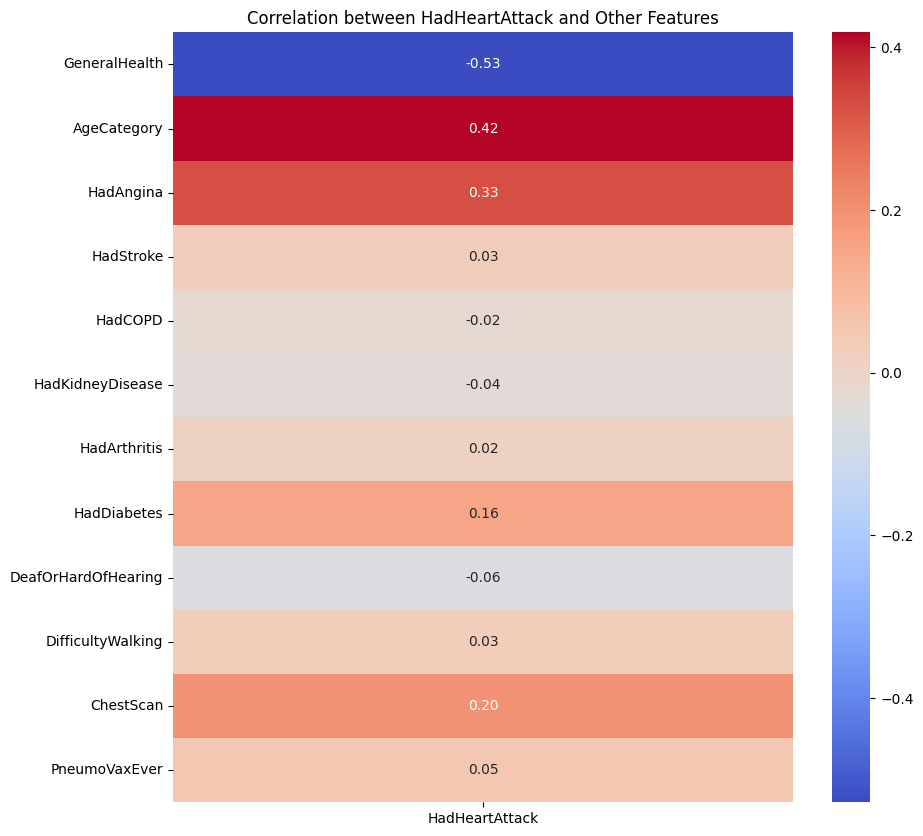

In [ ]:
HadHeartAttack_corr = df.corr()['HadHeartAttack']


HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')
plt.figure(figsize=(10, 10))
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between HadHeartAttack and Other Features')

plt.show()

In [ ]:
df.drop(['HadCOPD','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','PneumoVaxEver'],axis=1,inplace=True)

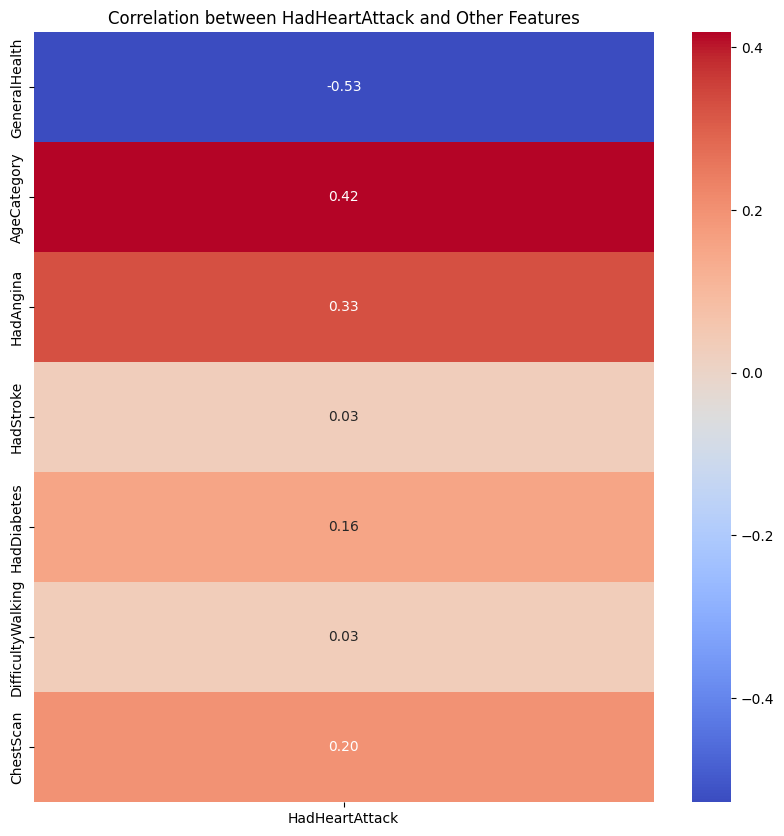

In [ ]:
HadHeartAttack_corr = df.corr()['HadHeartAttack']


HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')
plt.figure(figsize=(10, 10))
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between HadHeartAttack and Other Features')

plt.show()

In [ ]:
df.drop(['HadStroke','DifficultyWalking'],axis=1,inplace=True)

In [ ]:
df.shape

(448858, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   GeneralHealth   448858 non-null  int64
 1   AgeCategory     448858 non-null  int64
 2   HadAngina       448858 non-null  int64
 3   HadDiabetes     448858 non-null  int64
 4   ChestScan       448858 non-null  int64
 5   HadHeartAttack  448858 non-null  int64
dtypes: int64(6)
memory usage: 20.5 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features = ['GeneralHealth','AgeCategory','HadAngina','HadDiabetes','ChestScan']


scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])


scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
X=df[['GeneralHealth','AgeCategory','HadAngina','HadDiabetes','ChestScan']]
y=df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.79


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.89


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,   # increase cache
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train, y_train)
svclassifier.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.4998351379049147

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.89


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()

In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.784433592357596
Fold 2 Accuracy: 0.7876773365651957
Fold 3 Accuracy: 0.7908282389006719
Fold 4 Accuracy: 0.7844119272105085
Fold 5 Accuracy: 0.7882795373126348
Fold 6 Accuracy: 0.7897232074429216
Fold 7 Accuracy: 0.7862298821893882
Fold 8 Accuracy: 0.789758853618978

 Best Fold: 3 with Accuracy: 0.7908282389006719


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.7908282389006719

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8843459817848041

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.884417274136917

# **DL**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(256,input_shape=(5,),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_X_train,best_y_train,epochs=100,batch_size=32)

Epoch 1/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8042 - loss: 0.4250
Epoch 2/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.8115 - loss: 0.4081
Epoch 3/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8231 - loss: 0.3927
Epoch 4/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.8317 - loss: 0.3746
Epoch 5/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8356 - loss: 0.3638
Epoch 6/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8424 - loss: 0.3553
Epoch 7/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8471 - loss: 0.3455
Epoch 8/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8556 - loss: 0.3325
Epoch 9/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8602 - loss: 0.3212
Epoch 10/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8617 - loss: 0.3188
Epoch 11/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8625 - loss: 0.3145
Epoch 12

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

4209/4209 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8799 - loss: 0.2711
model accuracy:87.99%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
X_test

,GeneralHealth,AgeCategory,HadAngina,HadDiabetes,ChestScan
5,3,77,0,0,1
15,2,67,0,0,0
18,3,27,0,0,0
36,2,62,0,0,1
37,1,82,0,0,1
...,...,...,...,...,...
448832,2,72,1,1,1
448834,1,82,0,0,0
448846,2,81,1,0,1
448850,1,71,0,0,1


In [ ]:
y_test

,HadHeartAttack
5,0
15,0
18,0
36,1
37,0
...,...
448832,1
448834,1
448846,1
448850,1


In [ ]:
import pickle
with open("heartTree model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/heartTree model.pkl","rb") as file:
  load_model=pickle.load(file)

In [ ]:
load_model.predict([[3,77,0,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
load_model.predict([[0,72,1,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

# **Conclusion**
In this project, heart disease prediction was performed using machine learning and deep learning techniques. Exploratory Data Analysis (EDA) helped understand the dataset and identify class imbalance. The imbalance issue was handled using SMOTE, which improved model learning and prediction reliability.

Multiple machine learning models were evaluated using K-Fold Cross Validation. Among them, the Decision Tree Classifier achieved the highest accuracy of 88%, making it the best-performing model. Deep learning models were also implemented for comparison. The final model was saved in pickle format for future deployment.

This project shows that proper preprocessing and model evaluation can significantly improve prediction performance and support early heart disease detection.